## RQ2: Fairness Analysis — Do Mortgage Approval Outcomes Differ Across Demographic Groups?
#### Group 6 | Francesco Biedermann (FB2709) | Brian Hsu (CH4004) | Phoebe Zhao (PYZ2001)
#### APAN5205 Applied Machine Learning 2 | Prof. Andrew Assing

This notebook addresses Research Question 2: *"Do mortgage approval outcomes and model predictions differ systematically across demographic groups defined by race, ethnicity, and sex?"*

We conduct a two-part fairness analysis:
- **Part A — Descriptive Fairness:** We examine raw approval rates across demographic groups to identify disparities in observed outcomes in the full dataset.
- **Part B — Model Fairness:** We apply the best-performing model from RQ1 (Random Forest) to the held-out test set and compute Accuracy, Precision, Recall, F1-Score, and AUC-ROC separately for each demographic group, assessing whether the model performs equally well across groups.

Note that demographic variables were intentionally excluded from the predictive models in RQ1. Part B examines whether disparities persist in model predictions despite that exclusion — a phenomenon known as **proxy discrimination**, where non-demographic features (e.g. income, loan amount, property location) inadvertently encode demographic information.

**Part C — Interest Rate Fairness (Placeholder):** A third analysis examining whether approved applicants from different demographic groups receive systematically different interest rates is prepared below. It requires the `interest_rate` column to be merged back from the raw HMDA data. See the placeholder section at the end of this notebook.

### Step 1 | Setup and Data Loading
We import the required libraries and load the cleaned HMDA dataset. We then reconstruct the exact same feature matrix and train-test split used in RQ1 — using identical parameters (`test_size=0.30`, `random_state=42`, `stratify=y`) — so that the test set is identical across both notebooks. The demographic labels for test-set applicants are preserved in a separate dataframe and used exclusively for slicing predictions in Part B.

In [1]:
# Step 1: Setup and Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

# Load cleaned data
df = pd.read_csv('hmda_2024_cleaned.csv')

print('Dataset shape:', df.shape)
print('Approval rate:', round(df['approved'].mean() * 100, 2), '%')
print('\nDemographic columns confirmed present:', ['derived_race', 'derived_ethnicity', 'derived_sex'])

Dataset shape: (433173, 32)
Approval rate: 77.36 %

Demographic columns confirmed present: ['derived_race', 'derived_ethnicity', 'derived_sex']


### Step 2 | Reconstruct Feature Matrix and Train-Test Split
We replicate the exact preprocessing pipeline from RQ1:
- Exclude demographic columns from the feature matrix (reserved for fairness analysis)
- Drop `reverse_mortgage` (constant after cleaning) and `interest_rate_missing` (leaky — determined by the outcome)
- One-hot encode `state_code` with `drop_first=True`
- Apply a 70/30 stratified train-test split with `random_state=42`

Critically, we also store the demographic labels for each test-set observation in a separate dataframe (`demo_test`). This allows us to slice test predictions by demographic group without those variables ever entering the model.

In [2]:
# Step 2: Reconstruct Feature Matrix and Train-Test Split

# Define target
y = df['approved']

# Columns to exclude from modeling (same as RQ1)
drop_cols = [
    'approved',
    'derived_race',
    'derived_ethnicity',
    'derived_sex',
    'reverse_mortgage',
    'interest_rate_missing'
]

X = df.drop(columns=drop_cols)
X = pd.get_dummies(X, columns=['state_code'], drop_first=True)

print('Feature matrix shape:', X.shape)

# Train-test split — identical parameters to RQ1
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print('Training set:', X_train.shape[0], 'rows')
print('Test set:    ', X_test.shape[0], 'rows')
print('Approval rate - Train:', round(y_train.mean() * 100, 2), '%')
print('Approval rate - Test: ', round(y_test.mean() * 100, 2), '%')

# Preserve demographic labels for test set rows using original dataframe index
demo_test = df.loc[X_test.index, ['derived_race', 'derived_ethnicity', 'derived_sex']].copy()
demo_test['approved'] = y_test.values

print('\nDemographic label dataframe shape:', demo_test.shape)
print('Index alignment check (should be True):', (demo_test.index == X_test.index).all())

Feature matrix shape: (433173, 78)
Training set: 303221 rows
Test set:     129952 rows
Approval rate - Train: 77.36 %
Approval rate - Test:  77.36 %

Demographic label dataframe shape: (129952, 4)
Index alignment check (should be True): True


### Step 3 | Retrain Best Model from RQ1 (Random Forest)
We retrain the best-performing model identified in RQ1 — a Random Forest, tuned via 5-fold cross-validation on a 50,000-row subsample. Retraining here (rather than loading a saved model file) ensures full reproducibility within this notebook. The model is trained on the full training set and evaluated on the identical held-out test set used in RQ1. The overall test-set performance printed below should match the figures reported in RQ1.

In [3]:
# Step 3: Retrain Best Random Forest from RQ1

# Draw same tuning subsample as RQ1
X_tune, _, y_tune, _ = train_test_split(
    X_train, y_train, train_size=50000, random_state=42, stratify=y_train
)

forest = RandomForestClassifier(random_state=42, n_jobs=-1)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15]
}

tune_forest = GridSearchCV(
    estimator=forest,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

tune_forest.fit(X_tune, y_tune)

print('Best parameters:', tune_forest.best_params_)
print('Best CV AUC-ROC:', round(tune_forest.best_score_, 4))

# Refit on full training data
best_forest = tune_forest.best_estimator_
best_forest.fit(X_train, y_train)
print('\nRandom Forest refitted on full training data.')

# Generate predictions on test set
y_pred = best_forest.predict(X_test)
y_prob = best_forest.predict_proba(X_test)[:, 1]

# Overall performance — cross-check with RQ1
print('\nOverall Test Set Performance (should match RQ1):')
print('  Accuracy: ', round(accuracy_score(y_test, y_pred), 4))
print('  Precision:', round(precision_score(y_test, y_pred), 4))
print('  Recall:   ', round(recall_score(y_test, y_pred), 4))
print('  F1-Score: ', round(f1_score(y_test, y_pred), 4))
print('  AUC-ROC:  ', round(roc_auc_score(y_test, y_prob), 4))

# Attach predictions to demographic dataframe
demo_test['predicted'] = y_pred
demo_test['predicted_prob'] = y_prob

Best parameters: {'max_depth': 15, 'n_estimators': 200}
Best CV AUC-ROC: 0.868

Random Forest refitted on full training data.

Overall Test Set Performance (should match RQ1):
  Accuracy:  0.8691
  Precision: 0.8669
  Recall:    0.9815
  F1-Score:  0.9206
  AUC-ROC:   0.8738


---
## Part A — Descriptive Fairness: Raw Approval Rates by Demographic Group

Before examining model behaviour, we first describe the observed approval rates across demographic groups in the full dataset. This establishes the baseline disparity in outcomes and motivates the model fairness analysis in Part B.

Groups with fewer than 200 observations ("Free Form Text Only" in race and ethnicity) are excluded from visualisations as they are too small for reliable comparison. The overall approval rate is shown as a reference line throughout.

### Step 4 | Approval Rates by Race

Approval Rates by Race:
                                           approval_rate_pct       n
derived_race                                                        
2 or more minority races                               63.57    1076
Native Hawaiian or Other Pacific Islander              64.26    1052
Black or African American                              65.66   38042
American Indian or Alaska Native                       65.70    3283
Race Not Available                                     71.56   66364
White                                                  80.05  285557
Asian                                                  80.24   27731
Joint                                                  82.61    9937

Overall approval rate: 77.36%


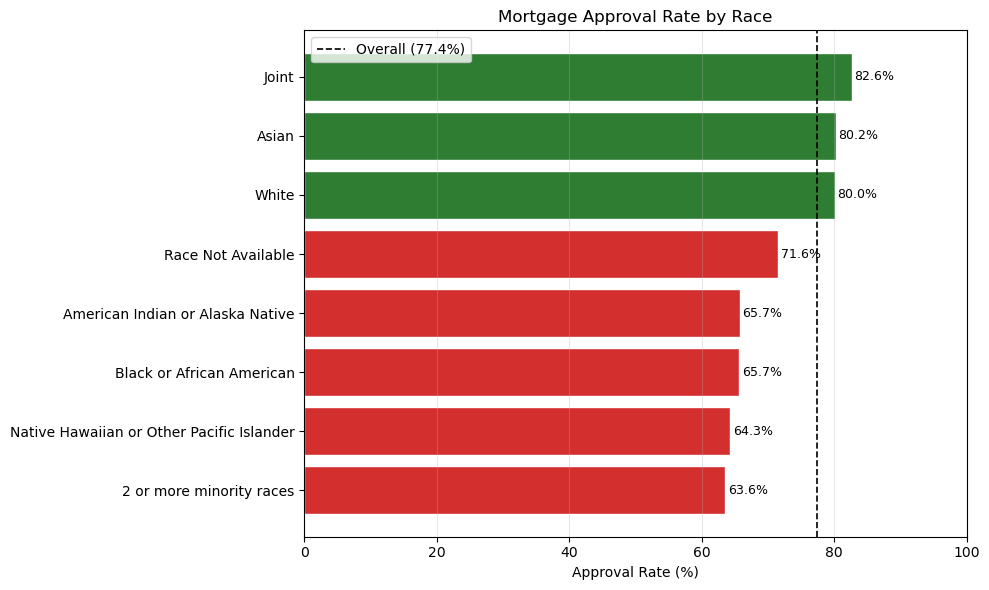

In [4]:
# Step 4: Approval Rates by Race

EXCLUDE_SMALL = ['Free Form Text Only']
overall_rate = df['approved'].mean()

race_stats = (
    df[~df['derived_race'].isin(EXCLUDE_SMALL)]
    .groupby('derived_race')['approved']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'approval_rate', 'count': 'n'})
    .sort_values('approval_rate', ascending=True)
)
race_stats['approval_rate_pct'] = (race_stats['approval_rate'] * 100).round(2)

print('Approval Rates by Race:')
print(race_stats[['approval_rate_pct', 'n']].to_string())
print(f'\nOverall approval rate: {round(overall_rate * 100, 2)}%')

colors = ['#d32f2f' if r < overall_rate else '#2e7d32' for r in race_stats['approval_rate']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(race_stats.index, race_stats['approval_rate_pct'], color=colors, edgecolor='white')
ax.axvline(overall_rate * 100, color='black', linewidth=1.2, linestyle='--',
           label=f'Overall ({round(overall_rate * 100, 1)}%)')

for bar, val in zip(bars, race_stats['approval_rate_pct']):
    ax.text(val + 0.4, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.set_xlabel('Approval Rate (%)')
ax.set_title('Mortgage Approval Rate by Race')
ax.set_xlim(0, 100)
ax.legend()
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### Step 5 | Approval Rates by Ethnicity

Approval Rates by Ethnicity:
                         approval_rate_pct       n
derived_ethnicity                                 
Hispanic or Latino                   71.88   54740
Ethnicity Not Available              72.09   60305
Not Hispanic or Latino               79.24  306304
Joint                                81.35   11643


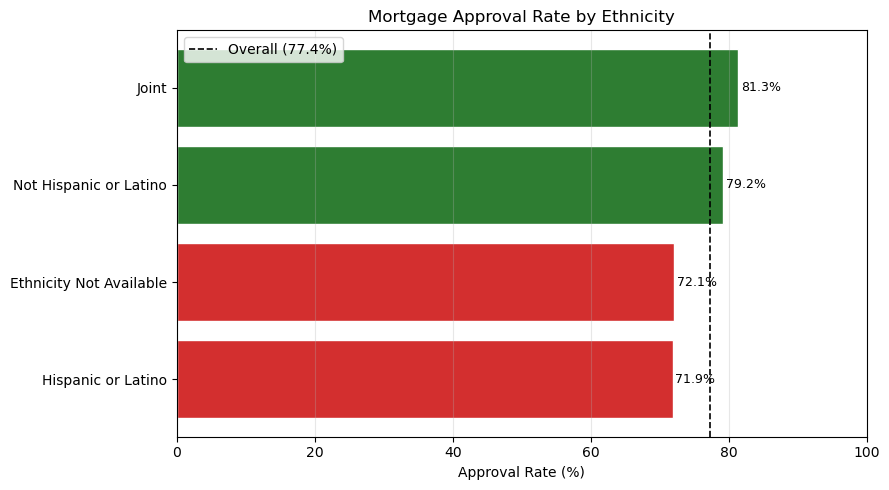

In [5]:
# Step 5: Approval Rates by Ethnicity

eth_stats = (
    df[~df['derived_ethnicity'].isin(EXCLUDE_SMALL)]
    .groupby('derived_ethnicity')['approved']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'approval_rate', 'count': 'n'})
    .sort_values('approval_rate', ascending=True)
)
eth_stats['approval_rate_pct'] = (eth_stats['approval_rate'] * 100).round(2)

print('Approval Rates by Ethnicity:')
print(eth_stats[['approval_rate_pct', 'n']].to_string())

colors = ['#d32f2f' if r < overall_rate else '#2e7d32' for r in eth_stats['approval_rate']]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(eth_stats.index, eth_stats['approval_rate_pct'], color=colors, edgecolor='white')
ax.axvline(overall_rate * 100, color='black', linewidth=1.2, linestyle='--',
           label=f'Overall ({round(overall_rate * 100, 1)}%)')

for bar, val in zip(bars, eth_stats['approval_rate_pct']):
    ax.text(val + 0.4, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.set_xlabel('Approval Rate (%)')
ax.set_title('Mortgage Approval Rate by Ethnicity')
ax.set_xlim(0, 100)
ax.legend()
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### Step 6 | Approval Rates by Sex

Approval Rates by Sex:
                   approval_rate_pct       n
derived_sex                                 
Sex Not Available              69.73   27889
Female                         73.13   99771
Male                           75.51  150001
Joint                          83.22  155512


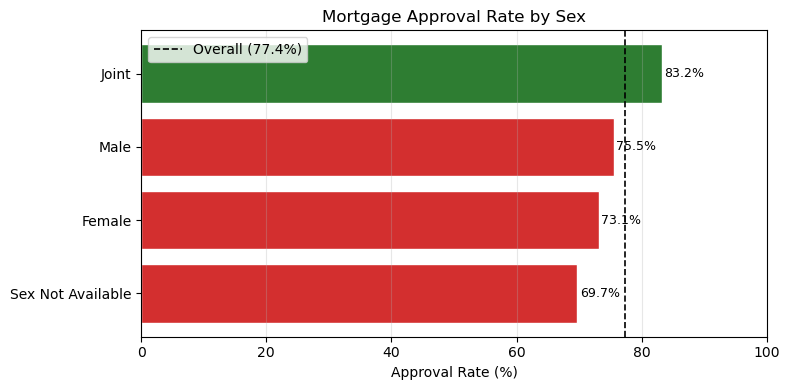

In [6]:
# Step 6: Approval Rates by Sex

sex_stats = (
    df.groupby('derived_sex')['approved']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'approval_rate', 'count': 'n'})
    .sort_values('approval_rate', ascending=True)
)
sex_stats['approval_rate_pct'] = (sex_stats['approval_rate'] * 100).round(2)

print('Approval Rates by Sex:')
print(sex_stats[['approval_rate_pct', 'n']].to_string())

colors = ['#d32f2f' if r < overall_rate else '#2e7d32' for r in sex_stats['approval_rate']]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(sex_stats.index, sex_stats['approval_rate_pct'], color=colors, edgecolor='white')
ax.axvline(overall_rate * 100, color='black', linewidth=1.2, linestyle='--',
           label=f'Overall ({round(overall_rate * 100, 1)}%)')

for bar, val in zip(bars, sex_stats['approval_rate_pct']):
    ax.text(val + 0.4, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.set_xlabel('Approval Rate (%)')
ax.set_title('Mortgage Approval Rate by Sex')
ax.set_xlim(0, 100)
ax.legend()
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### Step 7 | Approval Rate Gap Summary (Part A)
We compute the approval rate gap between each group and the overall rate, and display all three demographic dimensions together in a single diverging bar chart.

Approval Rate Gap vs. Overall (percentage points):
                                           Dimension  approval_rate_pct       n  gap_vs_overall_pp
2 or more minority races                        Race              63.57    1076             -13.79
Native Hawaiian or Other Pacific Islander       Race              64.26    1052             -13.10
Black or African American                       Race              65.66   38042             -11.70
American Indian or Alaska Native                Race              65.70    3283             -11.66
Sex Not Available                                Sex              69.73   27889              -7.63
Race Not Available                              Race              71.56   66364              -5.80
Hispanic or Latino                         Ethnicity              71.88   54740              -5.48
Ethnicity Not Available                    Ethnicity              72.09   60305              -5.27
Female                                           Sex      

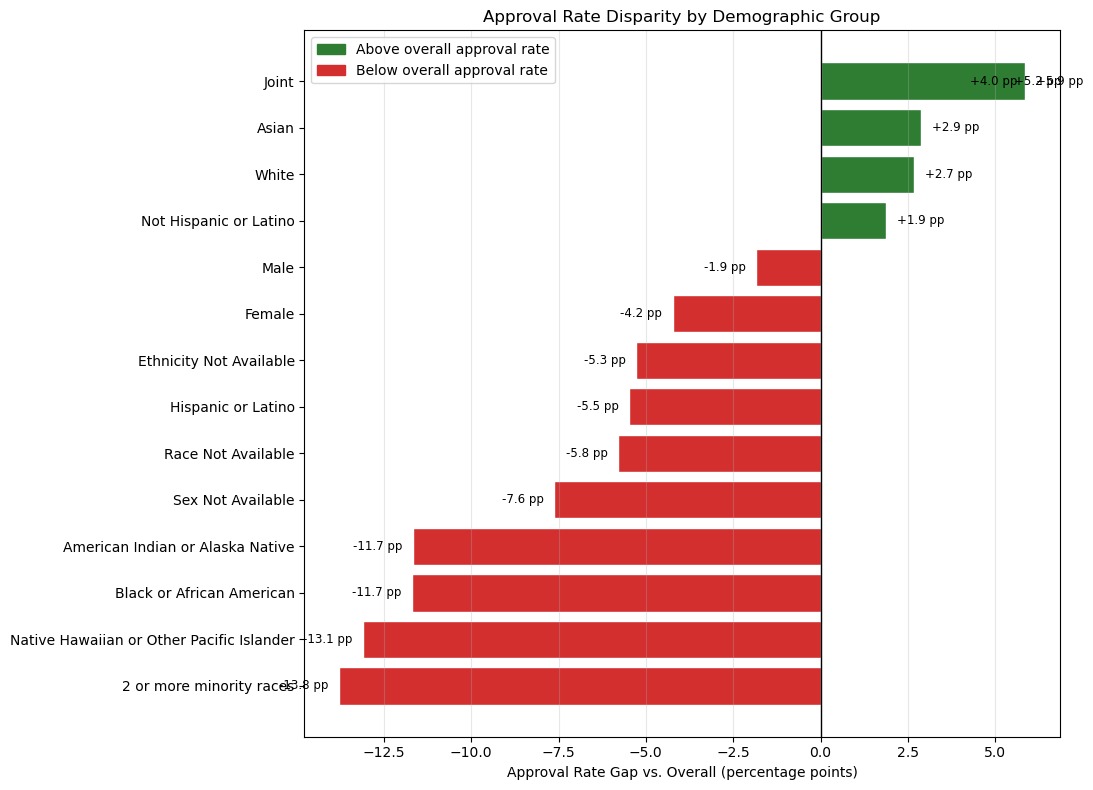

In [7]:
# Step 7: Approval Rate Gap Summary — All Dimensions

def gap_table(stats_df, dimension_label):
    t = stats_df[['approval_rate_pct', 'n']].copy()
    t['gap_vs_overall_pp'] = (t['approval_rate_pct'] - round(overall_rate * 100, 2)).round(2)
    t.insert(0, 'Dimension', dimension_label)
    return t

gap_summary = pd.concat([
    gap_table(race_stats, 'Race'),
    gap_table(eth_stats,  'Ethnicity'),
    gap_table(sex_stats,  'Sex')
]).sort_values('gap_vs_overall_pp')

print('Approval Rate Gap vs. Overall (percentage points):')
print(gap_summary.to_string())

# Diverging bar chart
fig, ax = plt.subplots(figsize=(11, 8))
colors = ['#d32f2f' if g < 0 else '#2e7d32' for g in gap_summary['gap_vs_overall_pp']]
bars = ax.barh(gap_summary.index, gap_summary['gap_vs_overall_pp'], color=colors, edgecolor='white')

for bar, val in zip(bars, gap_summary['gap_vs_overall_pp']):
    offset = 0.3 if val >= 0 else -0.3
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f'{val:+.1f} pp', va='center', ha=ha, fontsize=8.5)

ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Approval Rate Gap vs. Overall (percentage points)')
ax.set_title('Approval Rate Disparity by Demographic Group')
ax.grid(alpha=0.3, axis='x')

red_patch   = mpatches.Patch(color='#d32f2f', label='Below overall approval rate')
green_patch = mpatches.Patch(color='#2e7d32', label='Above overall approval rate')
ax.legend(handles=[green_patch, red_patch])

plt.tight_layout()
plt.show()

---
## Part B — Model Fairness: Prediction Performance Across Demographic Groups

We now evaluate the Random Forest model's predictions on the test set, segmented by demographic group. Even though demographic variables were excluded from the model, disparities in prediction quality can still emerge if other features are correlated with demographics (proxy discrimination). We compute five metrics per group: Accuracy, Precision, Recall, F1-Score, and AUC-ROC.

In a lending context, **Recall** is the most fairness-critical metric: low recall for a group means the model is systematically denying applicants from that group who should have been approved (false negatives). We highlight Recall gaps throughout this section.

### Step 8 | Helper Function: Per-Group Metrics
We define a reusable function that slices the test predictions by demographic group and returns a tidy metrics dataframe. It is applied identically across race, ethnicity, and sex.

In [8]:
# Step 8: Helper Function — Per-Group Fairness Metrics

MIN_GROUP_SIZE = 200  # exclude groups too small for reliable metrics

def fairness_metrics(demo_df, group_col, exclude_groups=None):
    """
    Compute fairness metrics for each group in group_col.
    Requires demo_df to contain: 'approved', 'predicted', 'predicted_prob'.
    Returns a DataFrame with one row per group.
    """
    if exclude_groups is None:
        exclude_groups = []

    rows = []
    for group, subset in demo_df.groupby(group_col):
        if group in exclude_groups or len(subset) < MIN_GROUP_SIZE:
            continue

        y_true = subset['approved']
        y_pred = subset['predicted']
        y_prob = subset['predicted_prob']

        # AUC-ROC requires at least one positive and one negative example
        auc = roc_auc_score(y_true, y_prob) if len(y_true.unique()) == 2 else np.nan

        rows.append({
            'Group': group,
            'N': len(subset),
            'Actual Approval Rate (%)':    round(y_true.mean() * 100, 2),
            'Predicted Approval Rate (%)': round(y_pred.mean() * 100, 2),
            'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
            'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
            'Recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
            'F1-Score':  round(f1_score(y_true, y_pred, zero_division=0), 4),
            'AUC-ROC':   round(auc, 4) if not np.isnan(auc) else np.nan
        })

    return pd.DataFrame(rows).set_index('Group')

print('Helper function defined.')
print(f'Groups with fewer than {MIN_GROUP_SIZE} test-set observations will be excluded.')

Helper function defined.
Groups with fewer than 200 test-set observations will be excluded.


### Step 9 | Model Fairness by Race

Model Performance by Race (test set):
                                               N  Actual Approval Rate (%)  Predicted Approval Rate (%)  Accuracy  Precision  Recall  F1-Score  AUC-ROC
Group                                                                                                                                                  
2 or more minority races                     326                     67.48                        79.14    0.8282     0.8178  0.9591    0.8828   0.8847
American Indian or Alaska Native            1014                     65.68                        77.61    0.8294     0.8132  0.9610    0.8809   0.8920
Asian                                       8307                     80.21                        89.80    0.8874     0.8839  0.9896    0.9338   0.8892
Black or African American                  11278                     65.82                        81.34    0.8119     0.7890  0.9751    0.8722   0.8627
Joint                                       3027  

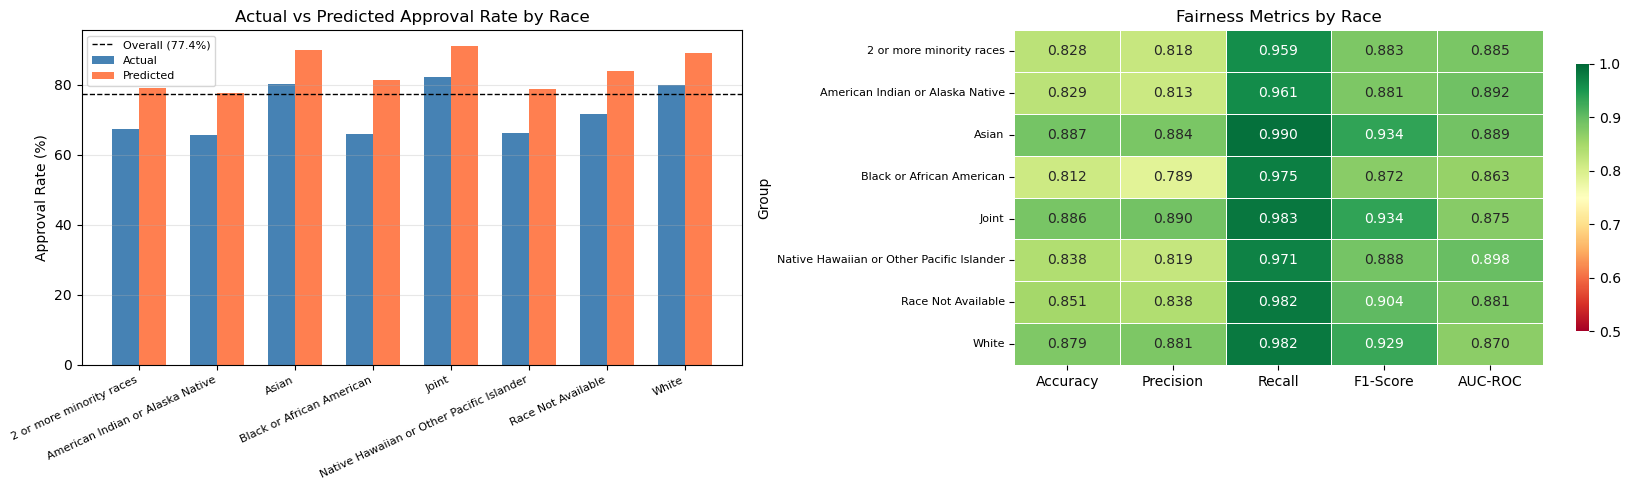

In [9]:
# Step 9: Model Fairness by Race

race_metrics = fairness_metrics(demo_test, 'derived_race', exclude_groups=['Free Form Text Only'])

print('Model Performance by Race (test set):')
print(race_metrics.to_string())

metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(17, 5))

# Left: Actual vs Predicted approval rate
ax = axes[0]
x = np.arange(len(race_metrics))
ax.bar(x - width/2, race_metrics['Actual Approval Rate (%)'],    width, label='Actual',    color='steelblue')
ax.bar(x + width/2, race_metrics['Predicted Approval Rate (%)'], width, label='Predicted', color='coral')
ax.axhline(overall_rate * 100, color='black', linewidth=1, linestyle='--',
           label=f'Overall ({round(overall_rate * 100, 1)}%)')
ax.set_xticks(x)
ax.set_xticklabels(race_metrics.index, rotation=25, ha='right', fontsize=8)
ax.set_ylabel('Approval Rate (%)')
ax.set_title('Actual vs Predicted Approval Rate by Race')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis='y')

# Right: Metrics heatmap
ax2 = axes[1]
sns.heatmap(
    race_metrics[metric_cols], annot=True, fmt='.3f',
    cmap='RdYlGn', vmin=0.5, vmax=1.0, ax=ax2,
    linewidths=0.5, cbar_kws={'shrink': 0.8}
)
ax2.set_title('Fairness Metrics by Race')
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

### Step 10 | Model Fairness by Ethnicity

Model Performance by Ethnicity (test set):
                             N  Actual Approval Rate (%)  Predicted Approval Rate (%)  Accuracy  Precision  Recall  F1-Score  AUC-ROC
Group                                                                                                                                
Ethnicity Not Available  18069                     72.37                        84.08    0.8557     0.8446  0.9812    0.9078   0.8820
Hispanic or Latino       16432                     71.98                        83.31    0.8480     0.8408  0.9731    0.9021   0.8753
Joint                     3518                     81.47                        89.88    0.8880     0.8909  0.9829    0.9346   0.8797
Not Hispanic or Latino   91874                     79.17                        88.97    0.8749     0.8746  0.9829    0.9256   0.8709


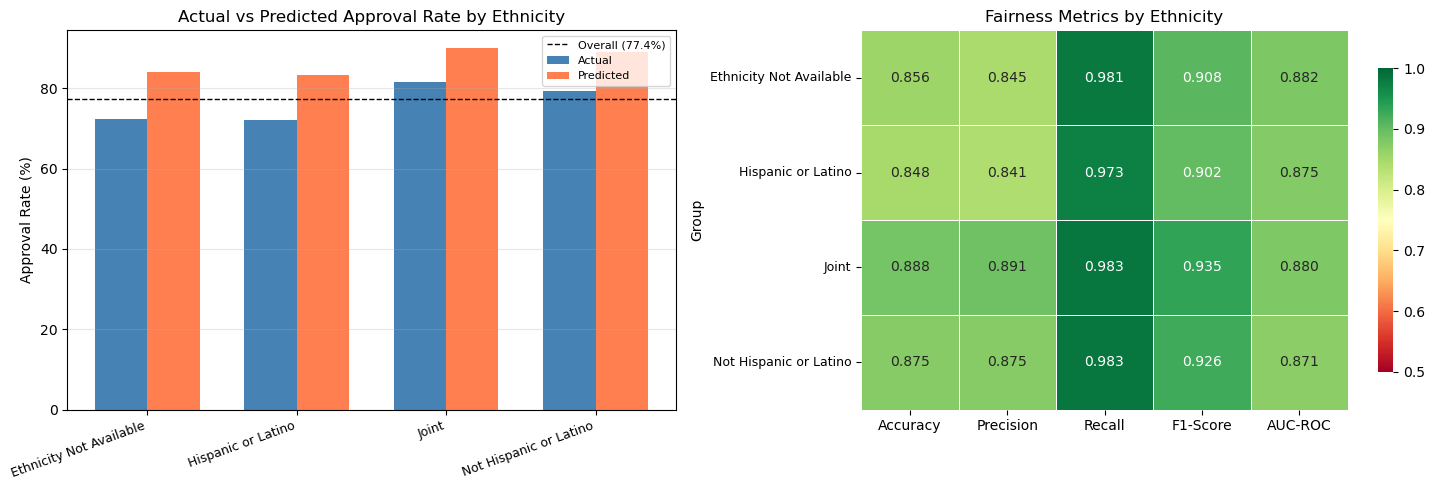

In [10]:
# Step 10: Model Fairness by Ethnicity

eth_metrics = fairness_metrics(demo_test, 'derived_ethnicity', exclude_groups=['Free Form Text Only'])

print('Model Performance by Ethnicity (test set):')
print(eth_metrics.to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
x = np.arange(len(eth_metrics))
ax.bar(x - width/2, eth_metrics['Actual Approval Rate (%)'],    width, label='Actual',    color='steelblue')
ax.bar(x + width/2, eth_metrics['Predicted Approval Rate (%)'], width, label='Predicted', color='coral')
ax.axhline(overall_rate * 100, color='black', linewidth=1, linestyle='--',
           label=f'Overall ({round(overall_rate * 100, 1)}%)')
ax.set_xticks(x)
ax.set_xticklabels(eth_metrics.index, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Approval Rate (%)')
ax.set_title('Actual vs Predicted Approval Rate by Ethnicity')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis='y')

ax2 = axes[1]
sns.heatmap(
    eth_metrics[metric_cols], annot=True, fmt='.3f',
    cmap='RdYlGn', vmin=0.5, vmax=1.0, ax=ax2,
    linewidths=0.5, cbar_kws={'shrink': 0.8}
)
ax2.set_title('Fairness Metrics by Ethnicity')
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

### Step 11 | Model Fairness by Sex

Model Performance by Sex (test set):
                       N  Actual Approval Rate (%)  Predicted Approval Rate (%)  Accuracy  Precision  Recall  F1-Score  AUC-ROC
Group                                                                                                                          
Female             29915                     73.24                        84.10    0.8583     0.8511  0.9774    0.9099   0.8781
Joint              46723                     83.17                        91.39    0.8899     0.8948  0.9832    0.9369   0.8642
Male               44942                     75.46                        86.86    0.8580     0.8526  0.9814    0.9125   0.8712
Sex Not Available   8372                     69.80                        82.75    0.8514     0.8320  0.9863    0.9026   0.8831


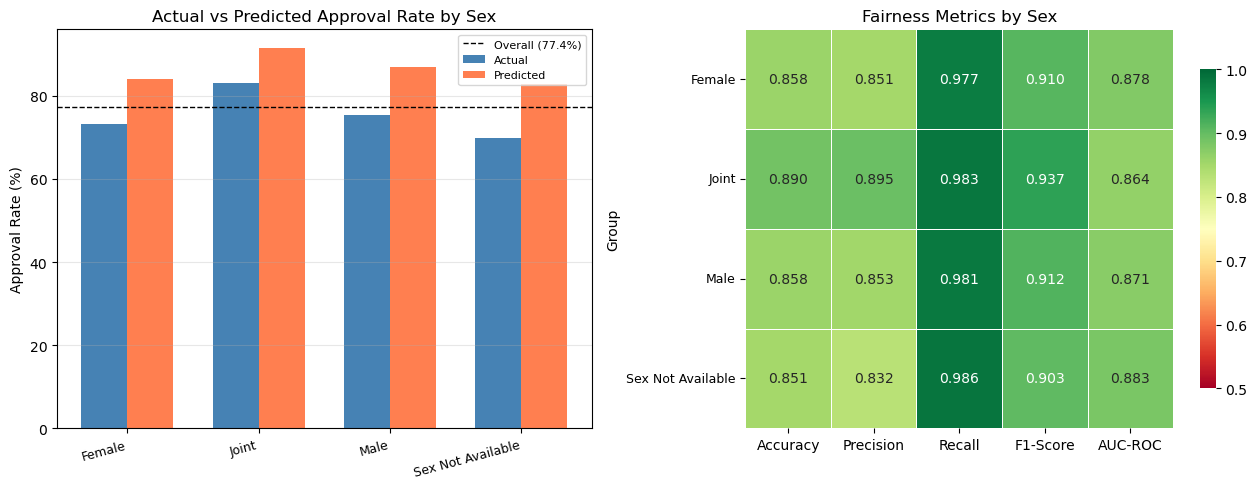

In [11]:
# Step 11: Model Fairness by Sex

sex_metrics = fairness_metrics(demo_test, 'derived_sex')

print('Model Performance by Sex (test set):')
print(sex_metrics.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
x = np.arange(len(sex_metrics))
ax.bar(x - width/2, sex_metrics['Actual Approval Rate (%)'],    width, label='Actual',    color='steelblue')
ax.bar(x + width/2, sex_metrics['Predicted Approval Rate (%)'], width, label='Predicted', color='coral')
ax.axhline(overall_rate * 100, color='black', linewidth=1, linestyle='--',
           label=f'Overall ({round(overall_rate * 100, 1)}%)')
ax.set_xticks(x)
ax.set_xticklabels(sex_metrics.index, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Approval Rate (%)')
ax.set_title('Actual vs Predicted Approval Rate by Sex')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis='y')

ax2 = axes[1]
sns.heatmap(
    sex_metrics[metric_cols], annot=True, fmt='.3f',
    cmap='RdYlGn', vmin=0.5, vmax=1.0, ax=ax2,
    linewidths=0.5, cbar_kws={'shrink': 0.8}
)
ax2.set_title('Fairness Metrics by Sex')
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

### Step 12 | Combined Fairness Summary and Recall Gap Chart
We combine the per-dimension metric tables into a single summary view. We then plot Recall across all groups — the most fairness-critical metric in a lending context — in a single diverging chart. A group with below-average Recall means the model is generating more false negatives for that group, i.e. systematically under-approving applicants who should qualify.

Combined Fairness Metrics — All Groups:
                                           Dimension      N  Actual Approval Rate (%)  Predicted Approval Rate (%)  Accuracy  Precision  Recall  F1-Score  AUC-ROC
Group                                                                                                                                                             
2 or more minority races                        Race    326                     67.48                        79.14    0.8282     0.8178  0.9591    0.8828   0.8847
American Indian or Alaska Native                Race   1014                     65.68                        77.61    0.8294     0.8132  0.9610    0.8809   0.8920
Native Hawaiian or Other Pacific Islander       Race    315                     66.35                        78.73    0.8381     0.8185  0.9713    0.8884   0.8982
Hispanic or Latino                         Ethnicity  16432                     71.98                        83.31    0.8480     0.8408  0.9731  

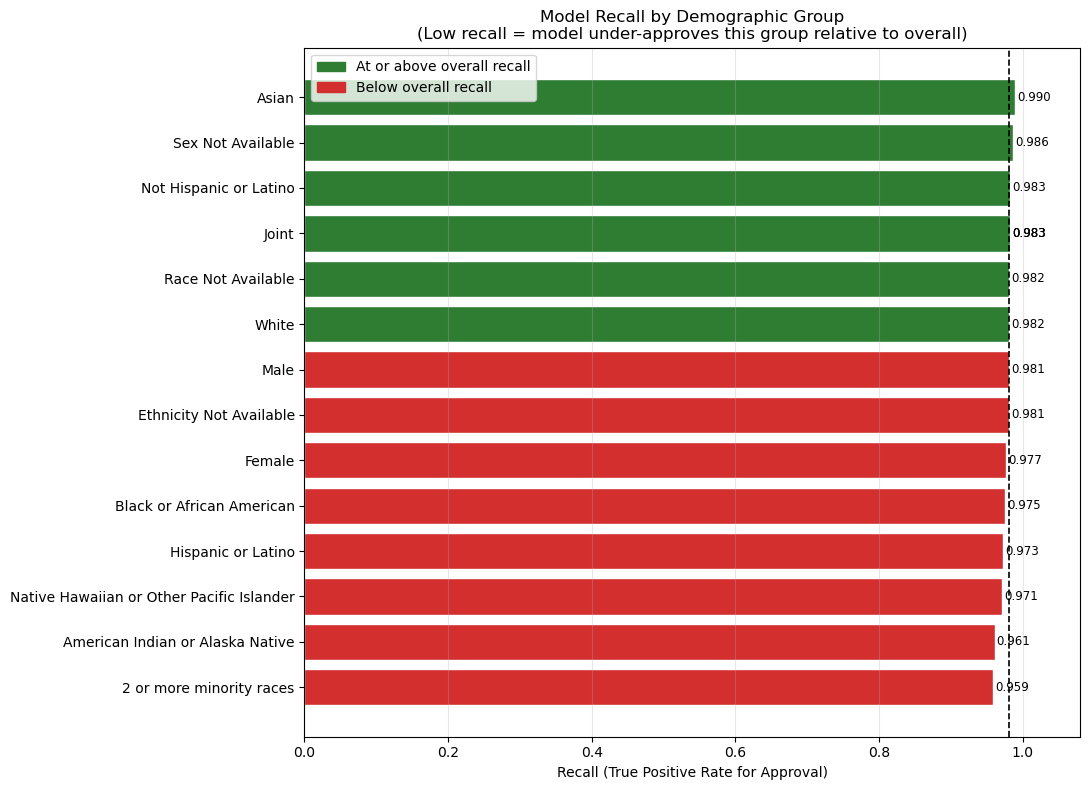

In [12]:
# Step 12: Combined Fairness Metrics Summary

def add_dimension(df, label):
    d = df.copy()
    d.insert(0, 'Dimension', label)
    return d

combined = pd.concat([
    add_dimension(race_metrics, 'Race'),
    add_dimension(eth_metrics,  'Ethnicity'),
    add_dimension(sex_metrics,  'Sex')
])

print('Combined Fairness Metrics — All Groups:')
print(combined.sort_values('Recall').to_string())

# --- Recall gap chart ---
overall_recall = recall_score(demo_test['approved'], demo_test['predicted'])
recall_vals = combined['Recall'].sort_values()

colors = ['#d32f2f' if r < overall_recall else '#2e7d32' for r in recall_vals]

fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(recall_vals.index, recall_vals, color=colors, edgecolor='white')
ax.axvline(overall_recall, color='black', linewidth=1.2, linestyle='--',
           label=f'Overall Recall ({round(overall_recall, 3)})')

for bar, val in zip(bars, recall_vals):
    ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=8.5)

ax.set_xlabel('Recall (True Positive Rate for Approval)')
ax.set_title('Model Recall by Demographic Group\n(Low recall = model under-approves this group relative to overall)')
ax.set_xlim(0, 1.08)
ax.grid(alpha=0.3, axis='x')

red_patch   = mpatches.Patch(color='#d32f2f', label='Below overall recall')
green_patch = mpatches.Patch(color='#2e7d32', label='At or above overall recall')
ax.legend(handles=[green_patch, red_patch])

plt.tight_layout()
plt.show()

## Part C — Interest Rate Fairness (Placeholder)

The `interest_rate` column was dropped from the cleaned dataset because it is only assigned post-approval, making it a target-leakage risk for the predictive models in RQ1. However, it is directly relevant here: even among approved applicants, certain demographic groups may receive systematically higher rates — a form of **pricing discrimination** distinct from the access discrimination measured in Parts A and B.

Only a placeholder now because I have yet to process the new dataset needed. 

In [15]:
# PLACEHOLDER — Part C: Interest Rate Fairness Analysis

# # Load dataset with interest rate merged back in
# df_rate = pd.read_csv('../data/hmda_2024_cleaned_with_rate.csv')

# # Keep approved applicants with a valid interest rate only
# df_approved = df_rate[
#     (df_rate['approved'] == 1) & (df_rate['interest_rate'].notna())
# ].copy()

# print(f'Approved applicants with a recorded interest rate: {len(df_approved):,}')
# print(f'Overall median interest rate: {df_approved["interest_rate"].median():.3f}%')
# print(f'Overall mean interest rate:   {df_approved["interest_rate"].mean():.3f}%')

# # --- Summary statistics by group ---
# MIN_RATE_N = 200

# def rate_summary(df_a, group_col, exclude=None):
#     if exclude is None:
#         exclude = []
#     stats = (
#         df_a[~df_a[group_col].isin(exclude)]
#         .groupby(group_col)['interest_rate']
#         .agg(
#             n='count',
#             mean='mean',
#             median='median',
#             std='std',
#             p25=lambda x: x.quantile(0.25),
#             p75=lambda x: x.quantile(0.75)
#         )
#     )
#     return stats[stats['n'] >= MIN_RATE_N].sort_values('median').round(4)

# for col, label in [
#     ('derived_race',      'Race'),
#     ('derived_ethnicity', 'Ethnicity'),
#     ('derived_sex',       'Sex')
# ]:
#     print(f'\n=== Interest Rate by {label} (Approved Applicants Only) ===')
#     print(rate_summary(df_approved, col, exclude=EXCLUDE_SMALL).to_string())

# # --- Box plots: interest rate distribution by demographic group ---
# fig, axes = plt.subplots(1, 3, figsize=(19, 6))

# overall_median_rate = df_approved['interest_rate'].median()

# for ax, (col, label) in zip(axes, [
#     ('derived_race',      'Race'),
#     ('derived_ethnicity', 'Ethnicity'),
#     ('derived_sex',       'Sex')
# ]):
#     plot_df = df_approved[~df_approved[col].isin(EXCLUDE_SMALL)]
#     order = plot_df.groupby(col)['interest_rate'].median().sort_values().index
#     sns.boxplot(
#         data=plot_df, y=col, x='interest_rate', order=order,
#         ax=ax, palette='RdYlGn_r',
#         flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3}
#     )
#     ax.axvline(overall_median_rate, color='black', linestyle='--', linewidth=1,
#                label=f'Overall median ({overall_median_rate:.2f}%)')
#     ax.set_xlabel('Interest Rate (%)')
#     ax.set_ylabel('')
#     ax.set_title(f'Interest Rate by {label}\n(Approved Applicants Only)')
#     ax.legend(fontsize=8)
#     ax.grid(alpha=0.3, axis='x')

# plt.tight_layout()
# plt.show()

print('Part C placeholder — uncomment cells above once interest_rate data is available.')

Part C placeholder — uncomment cells above once interest_rate data is available.


In [14]:
# ============================================================
# PLACEHOLDER — Part C: Interest Rate Fairness Analysis
# Uncomment all lines below once interest_rate has been merged back
# ============================================================

# # Load dataset with interest rate merged back in
# df_rate = pd.read_csv('../data/hmda_2024_cleaned_with_rate.csv')

# # Keep approved applicants with a valid interest rate only
# df_approved = df_rate[
#     (df_rate['approved'] == 1) & (df_rate['interest_rate'].notna())
# ].copy()

# print(f'Approved applicants with a recorded interest rate: {len(df_approved):,}')
# print(f'Overall median interest rate: {df_approved["interest_rate"].median():.3f}%')
# print(f'Overall mean interest rate:   {df_approved["interest_rate"].mean():.3f}%')

# # --- Summary statistics by group ---
# MIN_RATE_N = 200

# def rate_summary(df_a, group_col, exclude=None):
#     if exclude is None:
#         exclude = []
#     stats = (
#         df_a[~df_a[group_col].isin(exclude)]
#         .groupby(group_col)['interest_rate']
#         .agg(
#             n='count',
#             mean='mean',
#             median='median',
#             std='std',
#             p25=lambda x: x.quantile(0.25),
#             p75=lambda x: x.quantile(0.75)
#         )
#     )
#     return stats[stats['n'] >= MIN_RATE_N].sort_values('median').round(4)

# for col, label in [
#     ('derived_race',      'Race'),
#     ('derived_ethnicity', 'Ethnicity'),
#     ('derived_sex',       'Sex')
# ]:
#     print(f'\n=== Interest Rate by {label} (Approved Applicants Only) ===')
#     print(rate_summary(df_approved, col, exclude=EXCLUDE_SMALL).to_string())

# # --- Box plots: interest rate distribution by demographic group ---
# fig, axes = plt.subplots(1, 3, figsize=(19, 6))

# overall_median_rate = df_approved['interest_rate'].median()

# for ax, (col, label) in zip(axes, [
#     ('derived_race',      'Race'),
#     ('derived_ethnicity', 'Ethnicity'),
#     ('derived_sex',       'Sex')
# ]):
#     plot_df = df_approved[~df_approved[col].isin(EXCLUDE_SMALL)]
#     order = plot_df.groupby(col)['interest_rate'].median().sort_values().index
#     sns.boxplot(
#         data=plot_df, y=col, x='interest_rate', order=order,
#         ax=ax, palette='RdYlGn_r',
#         flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3}
#     )
#     ax.axvline(overall_median_rate, color='black', linestyle='--', linewidth=1,
#                label=f'Overall median ({overall_median_rate:.2f}%)')
#     ax.set_xlabel('Interest Rate (%)')
#     ax.set_ylabel('')
#     ax.set_title(f'Interest Rate by {label}\n(Approved Applicants Only)')
#     ax.legend(fontsize=8)
#     ax.grid(alpha=0.3, axis='x')

# plt.tight_layout()
# plt.show()

print('Part C placeholder — uncomment cells above once interest_rate data is available.')

Part C placeholder — uncomment cells above once interest_rate data is available.
